# Step 17: BTC-Only Regime Classifier (Naive Bayes)

## 🎯 Objective:
Melakukan eksperimen klasifikasi rezim yang **hanya menggunakan data BTC-USD** dengan menggunakan **Naive Bayes Classifier**.

## 🧠 Why Naive Bayes?
- **Probabilistic Nature**: Naive Bayes memberikan probabilitas yang dapat diinterpretasikan secara langsung.
- **Efficiency**: Sangat cepat untuk dilatih dan diprediksi.
- **Baseline**: Sering digunakan sebagai baseline yang kuat untuk masalah klasifikasi.

## 📊 Features (BTC-Only):
- `BTC_Vol_20`: Volatilitas 20 hari BTC.
- `BTC_Mom_20`: Momentum 20 hari BTC.
- `BTC_Mom_50`: Momentum 50 hari BTC.

## 🎓 Task:
- **Target**: Prediksi apakah BTC besok naik > 0.5% (Bullish = 1) atau tidak (Bearish = 0).
- **Train**: 2023-2024
- **Test**: 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Environment Ready for Naive Bayes Analysis!")

✅ Environment Ready for Naive Bayes Analysis!


## 1. Data Selection (BTC-USD Focus)

In [2]:
# Load data
try:
    df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset file not found. Creating dummy data for demonstration.")
    dates = pd.date_range(start='2023-01-01', end='2025-12-31')
    df = pd.DataFrame(index=dates)
    df['BTC-USD'] = 100 + np.cumsum(np.random.normal(0, 1, size=len(dates)))

btc_series = df['BTC-USD']
btc_ret = btc_series.pct_change().fillna(0)

print(f"📊 BTC Data Loaded. Range: {btc_series.index[0].date()} to {btc_series.index[-1].date()}")

Dataset loaded successfully.
📊 BTC Data Loaded. Range: 2023-04-17 to 2025-12-31


## 2. Feature Engineering (BTC Specific)

In [3]:
features = pd.DataFrame(index=btc_ret.index)

# Fitur 1: BTC Volatility
features['BTC_Vol_20'] = btc_ret.rolling(20).std()

# Fitur 2: BTC Momentum (Short)
features['BTC_Mom_20'] = btc_ret.rolling(20).mean()

# Fitur 3: BTC Momentum (Long)
features['BTC_Mom_50'] = btc_ret.rolling(50).mean()

# Target: Binary (Bullish if next day return > 0.5%)
features['Target'] = np.where(btc_ret.shift(-1) > 0.005, 1, 0)

features = features.dropna()

print("✅ BTC-Only Features Created.")
print(features.tail())

✅ BTC-Only Features Created.
            BTC_Vol_20  BTC_Mom_20  BTC_Mom_50  Target
Date                                                  
2025-12-27    0.014486   -0.001360   -0.003033       0
2025-12-28    0.014463   -0.001471   -0.002814       0
2025-12-29    0.013354   -0.003000   -0.003450       1
2025-12-30    0.013887   -0.001897   -0.003397       0
2025-12-31    0.013902   -0.002684   -0.003039       0


## 3. Train/Test Split (2025 Prediction)

In [4]:
train_idx = features.index.year < 2025
test_idx = features.index.year == 2025

X_train = features.loc[train_idx].drop(columns=['Target'])
y_train = features.loc[train_idx, 'Target']

X_test = features.loc[test_idx].drop(columns=['Target'])
y_test = features.loc[test_idx, 'Target']

# Scaling Features (Recommended for Gaussian Naive Bayes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📚 Training Samples: {len(X_train)}")
print(f"🧪 Testing Samples: {len(X_test)}")

📚 Training Samples: 576
🧪 Testing Samples: 365


## 4. Modeling & Results (Naive Bayes)


--- Naive Bayes Results ---
Accuracy: 63.84%
ROC-AUC : 0.5110

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.78       232
           1       0.60      0.02      0.04       133

    accuracy                           0.64       365
   macro avg       0.62      0.51      0.41       365
weighted avg       0.62      0.64      0.51       365



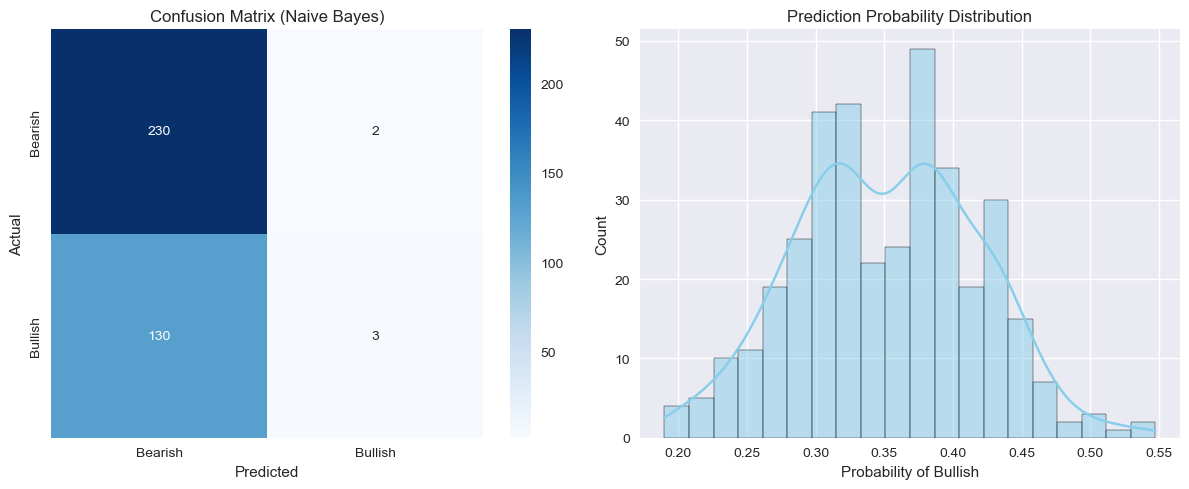

In [5]:
# Initialize Gaussian Naive Bayes
nb_model = GaussianNB()

# Fit Model
nb_model.fit(X_train_scaled, y_train)

# Predict
y_pred = nb_model.predict(X_test_scaled)
y_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"\n--- Naive Bayes Results ---")
print(f"Accuracy: {acc:.2%}")
print(f"ROC-AUC : {roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish', 'Bullish'], yticklabels=['Bearish', 'Bullish'])
plt.title('Confusion Matrix (Naive Bayes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Probability Distribution
plt.subplot(1, 2, 2)
sns.histplot(y_proba, kde=True, bins=20, color='skyblue')
plt.title('Prediction Probability Distribution')
plt.xlabel('Probability of Bullish')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Thesis Insight
Bandingkan hasil ini dengan Random Forest dan Logistic Regression. Jika Naive Bayes memberikan hasil yang lebih buruk, itu mungkin karena asumsi independensi fitur yang terlalu kuat (padahal Volatilitas dan Momentum mungkin berkorelasi), atau distribusi data yang tidak Gaussian.